# 🔬 Domain Adaptation: Integrasi EMNIST ke Dataset Gambo

**Tujuan:** Meratakan rasio kelas Normal vs Disleksia pada dataset DyslexiaLens dengan menambahkan data EMNIST yang telah di-preprocessing agar domain-nya cocok dengan Gambo.

---

### Latar Belakang
Dataset Gambo memiliki ketimpangan kelas:
| Kelas | Jumlah | Rasio |
|---|---|---|
| Normal | 39,334 | 1 |
| Disleksia | 112,315 | 2.86 |

Solusi: Ambil **72,981** gambar dari EMNIST, lakukan *Domain Adaptation*, lalu merge.

### Alur Notebook
1. **Fase Analisis** — Buktikan perbedaan domain Gambo vs EMNIST mentah
2. **Fase Preprocessing** — Transformasi EMNIST agar mirip Gambo
3. **Fase Validasi** — Buktikan preprocessing berhasil mendekatkan domain
4. **Fase Eksekusi** — Simpan 72,981 gambar yang sudah diproses

---
## Fase 1 — Analisis Domain: Gambo vs EMNIST Mentah
### 1.1 Setup & Load Data

In [1]:
import os, random, shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# === PATH ===
GAMBO_NORMAL_DIR   = 'Gambo/Train/Normal'
GAMBO_DYSLEXIA_DIR = 'Gambo/Train/Corrected'
EMNIST_NORMAL_DIR  = 'processed/emnist_byclass_images/train'
OUTPUT_DIR         = 'EMNIST_Processed'

# === PARAMETER ===
SAMPLE_SIZE = 2000
TARGET_SIZE = (28, 28)
NEEDED      = 72981
THRESHOLD   = 100
INNER_SIZE  = 20

def collect_png_paths(root_dir, max_files=None):
    paths = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.lower().endswith('.png'):
                if 'digit_' in dirpath:
                    continue
                paths.append(os.path.join(dirpath, f))
    if max_files and len(paths) > max_files:
        paths = random.sample(paths, max_files)
    return paths

def load_images_as_arrays(paths, size=TARGET_SIZE):
    arrays = []
    for p in paths:
        try:
            img = Image.open(p).convert('L').resize(size)
            arrays.append(np.array(img, dtype=np.float32))
        except Exception:
            continue
    return np.array(arrays)

print('📦 Mengumpulkan file gambar...')
gambo_paths    = collect_png_paths(GAMBO_NORMAL_DIR, SAMPLE_SIZE)
emnist_paths   = collect_png_paths(EMNIST_NORMAL_DIR, SAMPLE_SIZE)
dyslexia_paths = collect_png_paths(GAMBO_DYSLEXIA_DIR, SAMPLE_SIZE)

print(f'   Gambo Normal  : {len(gambo_paths):,}')
print(f'   EMNIST Normal : {len(emnist_paths):,}')
print(f'   Gambo Disleksia: {len(dyslexia_paths):,}')

print('\n🔄 Memuat gambar ke memori...')
gambo_imgs    = load_images_as_arrays(gambo_paths)
emnist_imgs   = load_images_as_arrays(emnist_paths)
dyslexia_imgs = load_images_as_arrays(dyslexia_paths)
print('Selesai! ✅')

📦 Mengumpulkan file gambar...
   Gambo Normal  : 2,000
   EMNIST Normal : 2,000
   Gambo Disleksia: 2,000

🔄 Memuat gambar ke memori...
Selesai! ✅


### 1.2 Perbandingan Visual (Sampel Acak)

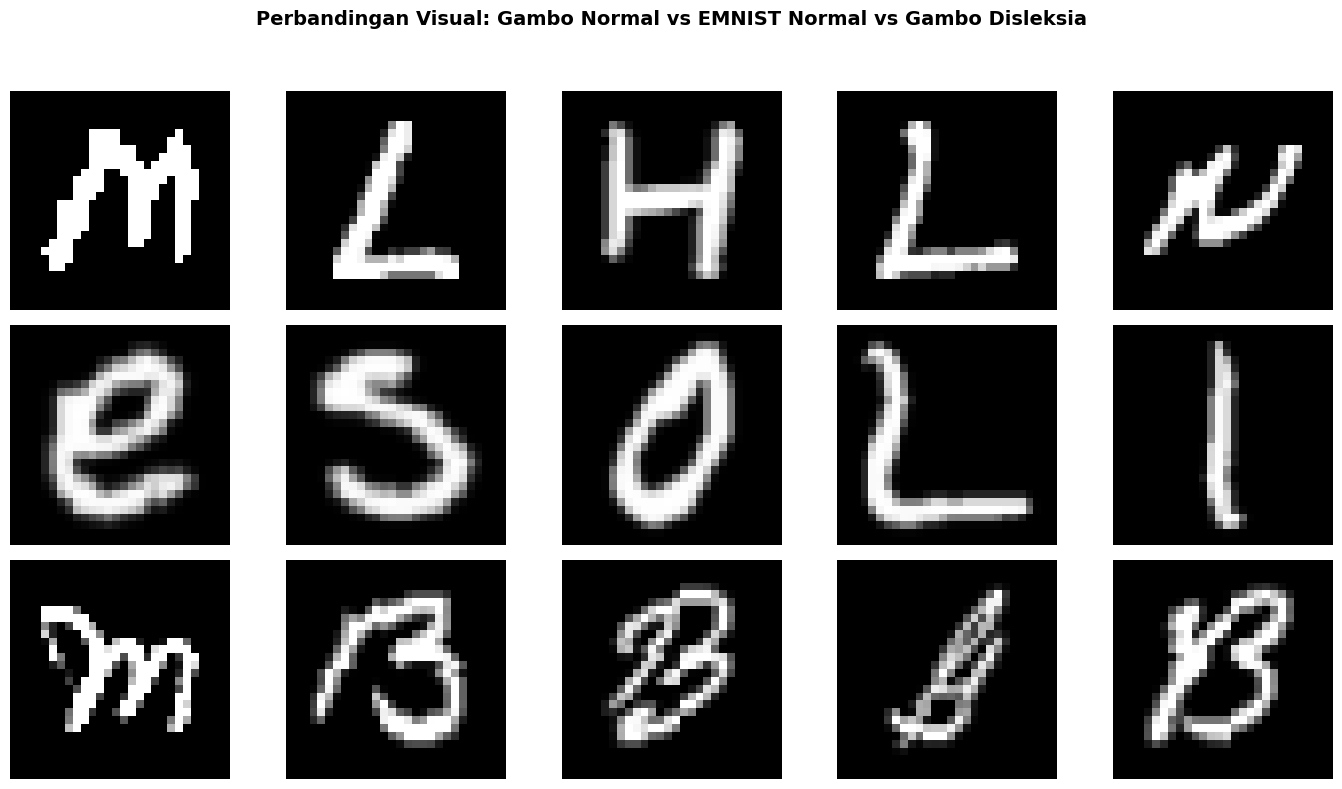

In [2]:
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Perbandingan Visual: Gambo Normal vs EMNIST Normal vs Gambo Disleksia',
             fontsize=14, fontweight='bold')

for row, (label, data) in enumerate(zip(
    ['Gambo Normal', 'EMNIST Normal', 'Gambo Disleksia'],
    [gambo_imgs, emnist_imgs, dyslexia_imgs])):
    indices = random.sample(range(len(data)), 5)
    for col, idx in enumerate(indices):
        axes[row, col].imshow(data[idx], cmap='gray', vmin=0, vmax=255)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=11, fontweight='bold',
                                       rotation=0, labelpad=100, va='center')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### 1.3 Histogram Intensitas Piksel

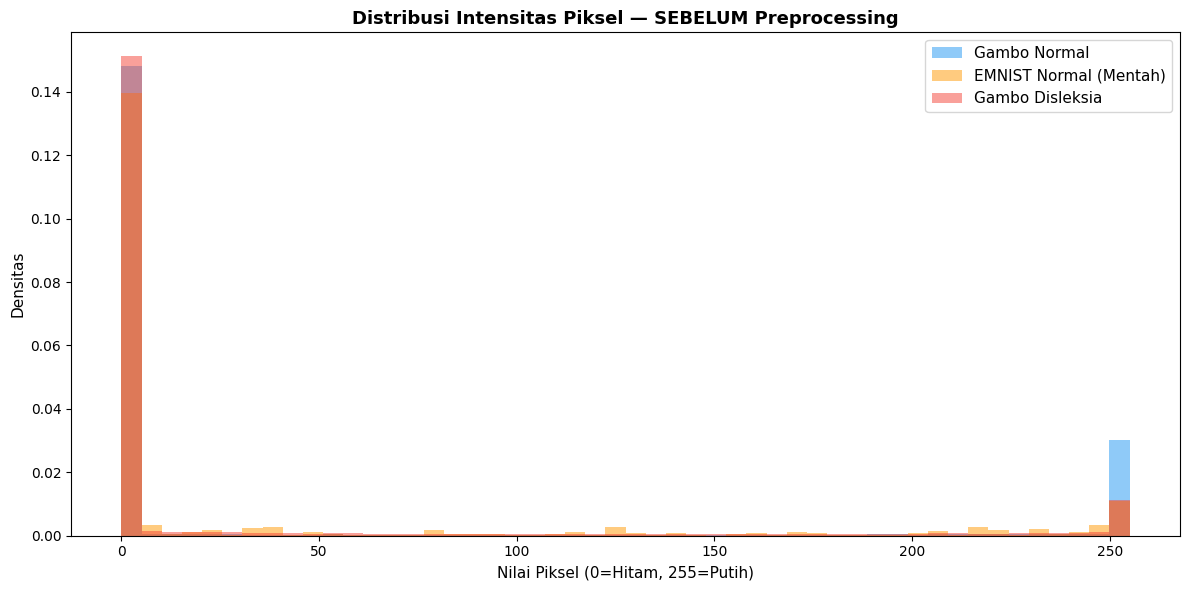

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(gambo_imgs.flatten(), bins=50, alpha=0.5, label='Gambo Normal', color='#2196F3', density=True)
ax.hist(emnist_imgs.flatten(), bins=50, alpha=0.5, label='EMNIST Normal (Mentah)', color='#FF9800', density=True)
ax.hist(dyslexia_imgs.flatten(), bins=50, alpha=0.5, label='Gambo Disleksia', color='#F44336', density=True)
ax.set_xlabel('Nilai Piksel (0=Hitam, 255=Putih)', fontsize=11)
ax.set_ylabel('Densitas', fontsize=11)
ax.set_title('Distribusi Intensitas Piksel — SEBELUM Preprocessing', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 1.4 Mean Heatmap & Statistik Jarak Domain

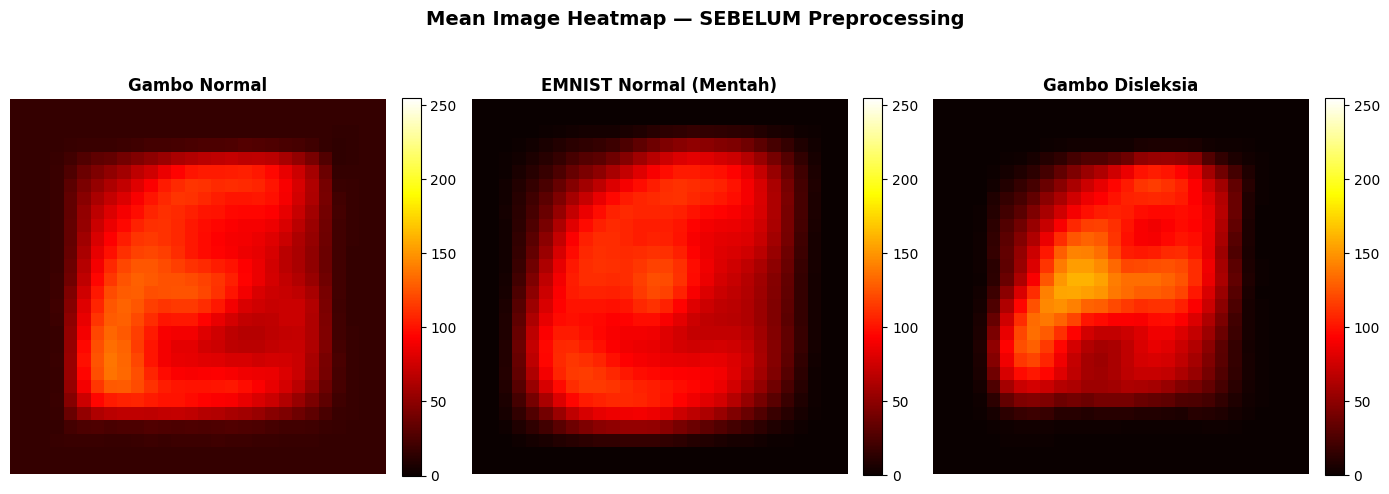

Jarak Domain Gambo↔EMNIST (Mentah) : 10.54 / 255
Jarak Domain Gambo↔Disleksia       : 20.51 / 255


In [4]:
gambo_mean    = gambo_imgs.mean(axis=0)
emnist_mean   = emnist_imgs.mean(axis=0)
dyslexia_mean = dyslexia_imgs.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Mean Image Heatmap — SEBELUM Preprocessing', fontsize=14, fontweight='bold')
for ax, title, m in zip(axes, ['Gambo Normal', 'EMNIST Normal (Mentah)', 'Gambo Disleksia'],
                               [gambo_mean, emnist_mean, dyslexia_mean]):
    im = ax.imshow(m, cmap='hot', vmin=0, vmax=255)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

mad_before = np.abs(gambo_mean - emnist_mean).mean()
mad_target = np.abs(gambo_mean - dyslexia_mean).mean()
print(f'Jarak Domain Gambo↔EMNIST (Mentah) : {mad_before:.2f} / 255')
print(f'Jarak Domain Gambo↔Disleksia       : {mad_target:.2f} / 255')

---
## Fase 2 — Domain Adaptation: Preprocessing EMNIST
### 2.1 Fungsi Preprocessing

In [5]:
def preprocess_emnist(img_path, threshold=THRESHOLD, inner_size=INNER_SIZE, target_size=TARGET_SIZE):
    """Transformasi EMNIST agar domain-nya mirip Gambo."""
    img = Image.open(img_path).convert('L')
    
    # 1. Binarisasi — hapus piksel abu-abu
    arr = np.array(img)
    arr = np.where(arr > threshold, 255, 0).astype(np.uint8)
    img = Image.fromarray(arr)
    
    # 2. Crop ke bounding box huruf
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)
    
    # 3. Resize ke inner_size (proporsi huruf mirip Gambo)
    img.thumbnail((inner_size, inner_size), Image.LANCZOS)
    
    # 4. Re-binarize (LANCZOS bisa bikin abu-abu lagi)
    arr = np.array(img)
    arr = np.where(arr > 128, 255, 0).astype(np.uint8)
    img = Image.fromarray(arr)
    
    # 5. Center pada canvas hitam 28x28
    canvas = Image.new('L', target_size, 0)
    px = (target_size[0] - img.width) // 2
    py = (target_size[1] - img.height) // 2
    canvas.paste(img, (px, py))
    
    return canvas

print('Fungsi preprocess_emnist() siap! ✅')

Fungsi preprocess_emnist() siap! ✅


### 2.2 Preview: EMNIST Asli → Processed → Target Gambo

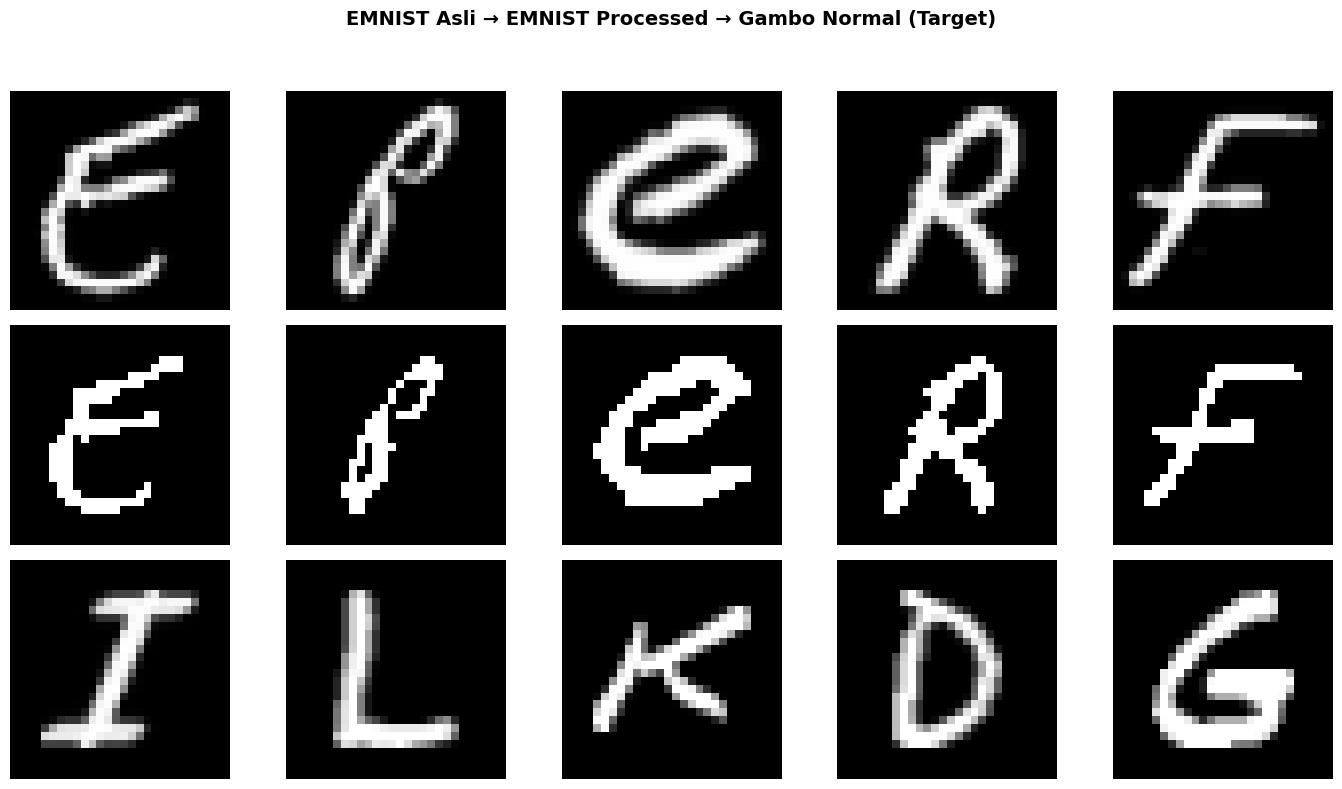

In [6]:
all_emnist = [f for d in os.listdir(EMNIST_NORMAL_DIR)
              if os.path.isdir(os.path.join(EMNIST_NORMAL_DIR, d))
              if not d.startswith('digit_')
              for f in [os.path.join(EMNIST_NORMAL_DIR, d, x)
                        for x in os.listdir(os.path.join(EMNIST_NORMAL_DIR, d))
                        if x.endswith('.png')]]

gambo_all = collect_png_paths(GAMBO_NORMAL_DIR)
sample_e = random.sample(all_emnist, 5)
sample_g = random.sample(gambo_all, 5)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('EMNIST Asli → EMNIST Processed → Gambo Normal (Target)', fontsize=14, fontweight='bold')

for col in range(5):
    orig = Image.open(sample_e[col]).convert('L').resize((28,28))
    axes[0, col].imshow(np.array(orig), cmap='gray', vmin=0, vmax=255)
    axes[0, col].axis('off')
    if col == 0: axes[0, col].set_ylabel('EMNIST\nAsli', fontsize=10, fontweight='bold', rotation=0, labelpad=60, va='center')

    proc = preprocess_emnist(sample_e[col])
    axes[1, col].imshow(np.array(proc), cmap='gray', vmin=0, vmax=255)
    axes[1, col].axis('off')
    if col == 0: axes[1, col].set_ylabel('EMNIST\nProcessed', fontsize=10, fontweight='bold', rotation=0, labelpad=60, va='center')

    gimg = Image.open(sample_g[col]).convert('L').resize((28,28))
    axes[2, col].imshow(np.array(gimg), cmap='gray', vmin=0, vmax=255)
    axes[2, col].axis('off')
    if col == 0: axes[2, col].set_ylabel('Gambo\nNormal', fontsize=10, fontweight='bold', rotation=0, labelpad=60, va='center')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

---
## Fase 3 — Validasi: Histogram & Heatmap SETELAH Preprocessing

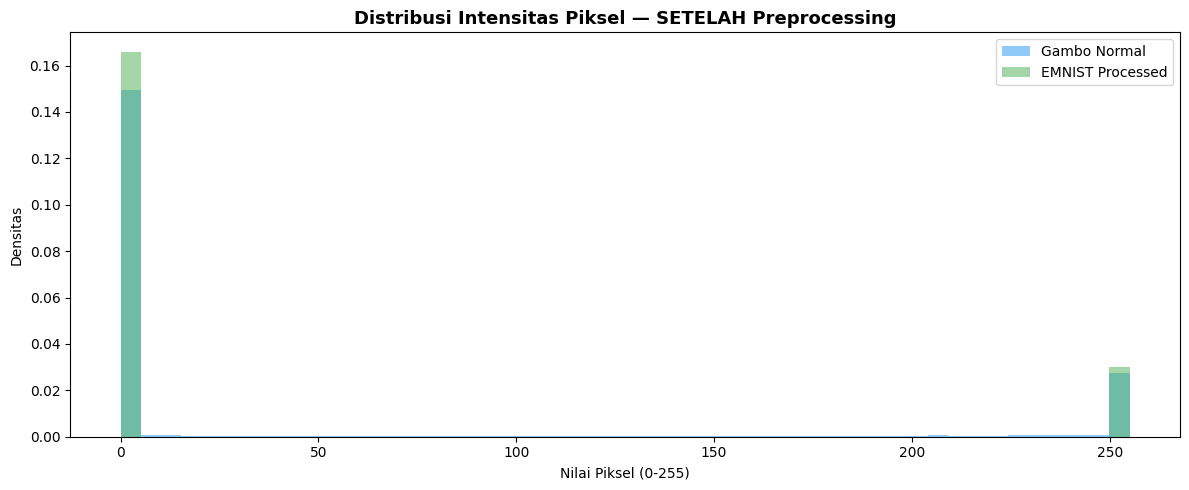

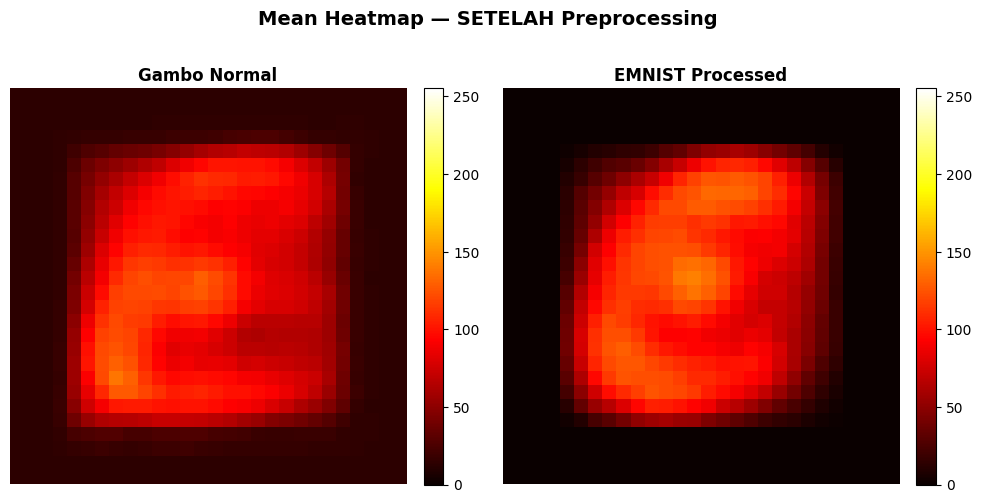


Jarak Domain SEBELUM preprocessing : 10.54 / 255
Jarak Domain SETELAH preprocessing : 15.08 / 255
Perubahan                          : -4.54 (negatif = membaik)


In [7]:
n_val = 1000
val_e = random.sample(all_emnist, n_val)
val_g = random.sample(gambo_all, min(n_val, len(gambo_all)))

proc_arr = np.array([np.array(preprocess_emnist(p), dtype=np.float32) for p in val_e])
gambo_arr = np.array([np.array(Image.open(p).convert('L').resize((28,28)), dtype=np.float32) for p in val_g])

# Histogram
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(gambo_arr.flatten(), bins=50, alpha=0.5, label='Gambo Normal', color='#2196F3', density=True)
ax.hist(proc_arr.flatten(), bins=50, alpha=0.5, label='EMNIST Processed', color='#4CAF50', density=True)
ax.set_xlabel('Nilai Piksel (0-255)')
ax.set_ylabel('Densitas')
ax.set_title('Distribusi Intensitas Piksel — SETELAH Preprocessing', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Heatmap
proc_mean = proc_arr.mean(axis=0)
gambo_m2  = gambo_arr.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Mean Heatmap — SETELAH Preprocessing', fontsize=14, fontweight='bold')
for ax, title, m in zip(axes, ['Gambo Normal', 'EMNIST Processed'], [gambo_m2, proc_mean]):
    im = ax.imshow(m, cmap='hot', vmin=0, vmax=255)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# MAD
mad_after = np.abs(gambo_m2 - proc_mean).mean()
print(f'\nJarak Domain SEBELUM preprocessing : {mad_before:.2f} / 255')
print(f'Jarak Domain SETELAH preprocessing : {mad_after:.2f} / 255')
print(f'Perubahan                          : {mad_before - mad_after:+.2f} (negatif = membaik)')

---
## Fase 4 — Eksekusi: Proses & Simpan 72,981 Gambar

⚠️ **Pastikan kamu puas dengan hasil Fase 2 & 3 sebelum menjalankan sel ini!**

In [8]:
# Hitung distribusi sampling per folder huruf
letter_files = {}
for folder in sorted(os.listdir(EMNIST_NORMAL_DIR)):
    fp = os.path.join(EMNIST_NORMAL_DIR, folder)
    if os.path.isdir(fp):
        if folder.startswith('digit_'): continue
        letter_files[folder] = [os.path.join(fp, f) for f in os.listdir(fp) if f.endswith('.png')]

num_folders = len(letter_files)
per_folder  = NEEDED // num_folders
remainder   = NEEDED % num_folders

sampling_plan = {}
for i, (folder, files) in enumerate(sorted(letter_files.items())):
    take = per_folder + (1 if i < remainder else 0)
    sampling_plan[folder] = min(take, len(files))

print(f'Folder huruf: {num_folders} | Per folder: ~{per_folder} | Total: {sum(sampling_plan.values()):,}')

Folder huruf: 52 | Per folder: ~1403 | Total: 72,981


In [9]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
saved = 0
errors = 0

for folder, take_count in sampling_plan.items():
    selected = random.sample(letter_files[folder], take_count)
    out_folder = os.path.join(OUTPUT_DIR, folder)
    os.makedirs(out_folder, exist_ok=True)
    
    for filepath in selected:
        try:
            img = preprocess_emnist(filepath)
            img.save(os.path.join(out_folder, f'emnist_{os.path.basename(filepath)}'))
            saved += 1
        except Exception:
            errors += 1
    
    if saved % 10000 < take_count:
        print(f'   Progres: {saved:,} / {NEEDED:,}')

print(f'\n✅ Selesai! {saved:,} gambar tersimpan ke {OUTPUT_DIR}/')
if errors: print(f'⚠️  {errors} gagal.')

   Progres: 11,232 / 72,981
   Progres: 21,060 / 72,981
   Progres: 30,888 / 72,981
   Progres: 40,712 / 72,981
   Progres: 50,533 / 72,981
   Progres: 60,354 / 72,981
   Progres: 70,175 / 72,981

✅ Selesai! 72,981 gambar tersimpan ke EMNIST_Processed/


---
## Fase 5 — Verifikasi Akhir: Rasio Kelas Setelah Merge

  RINGKASAN DATASET SETELAH MERGE
  Gambo Normal (asli)     : 39,334
  EMNIST Processed (baru) : 72,981
  Total Normal            : 112,315
  Total Disleksia         : 112,315
  Rasio Normal:Disleksia  : 1.00 : 1


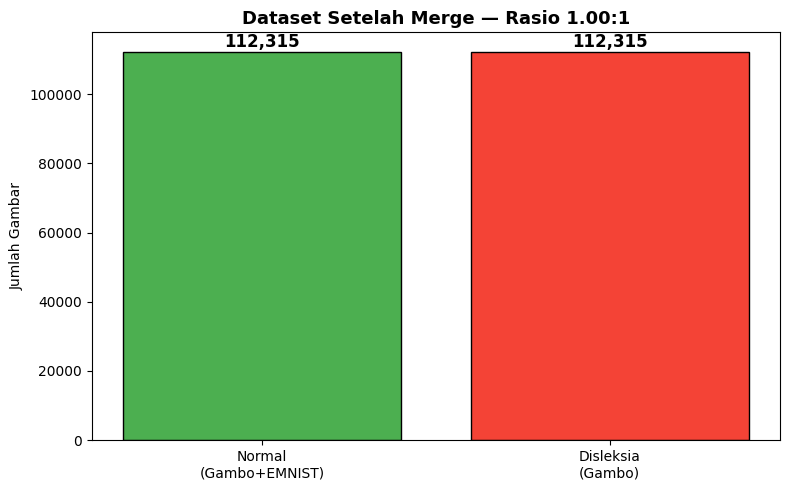


📌 Langkah selanjutnya:
   1. Salin isi EMNIST_Processed/ ke Gambo/Train/Normal/
   2. Update Dyslexia.ipynb untuk membaca data merged
   3. Re-train model dengan dataset yang sudah seimbang


In [10]:
total_proc = sum(1 for d,_,f in os.walk(OUTPUT_DIR) for x in f if x.endswith('.png'))
n_normal   = 39334 + total_proc
n_dyslexia = 112315

print('=' * 55)
print('  RINGKASAN DATASET SETELAH MERGE')
print('=' * 55)
print(f'  Gambo Normal (asli)     : 39,334')
print(f'  EMNIST Processed (baru) : {total_proc:,}')
print(f'  Total Normal            : {n_normal:,}')
print(f'  Total Disleksia         : {n_dyslexia:,}')
print(f'  Rasio Normal:Disleksia  : {n_normal/n_dyslexia:.2f} : 1')
print('=' * 55)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Normal\n(Gambo+EMNIST)', 'Disleksia\n(Gambo)'],
              [n_normal, n_dyslexia], color=['#4CAF50', '#F44336'], edgecolor='black')
ax.set_title(f'Dataset Setelah Merge — Rasio {n_normal/n_dyslexia:.2f}:1', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Gambar')
for bar, val in zip(bars, [n_normal, n_dyslexia]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1500, f'{val:,}',
            ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\n📌 Langkah selanjutnya:')
print('   1. Salin isi EMNIST_Processed/ ke Gambo/Train/Normal/')
print('   2. Update Dyslexia.ipynb untuk membaca data merged')
print('   3. Re-train model dengan dataset yang sudah seimbang')